# Tarea 3: Clasificación de galaxias con una CNN

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

<h1 style="color:royalblue">Noah Ancalao Y Cristóbal Manríquez</h1>

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [2]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [4]:
#cambie este path al correspondiente suyo, en su carpeta drive
path = "/content/drive/MyDrive/Colab Notebooks/Tarea_3/Binary_2_5_dataset.h5" #path Noah
#path = "/content/drive/MyDrive/Big Data (yo)/Tarea 3/Binary_2_5_dataset.h5" #path Cristóbal

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [5]:
#X

In [6]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

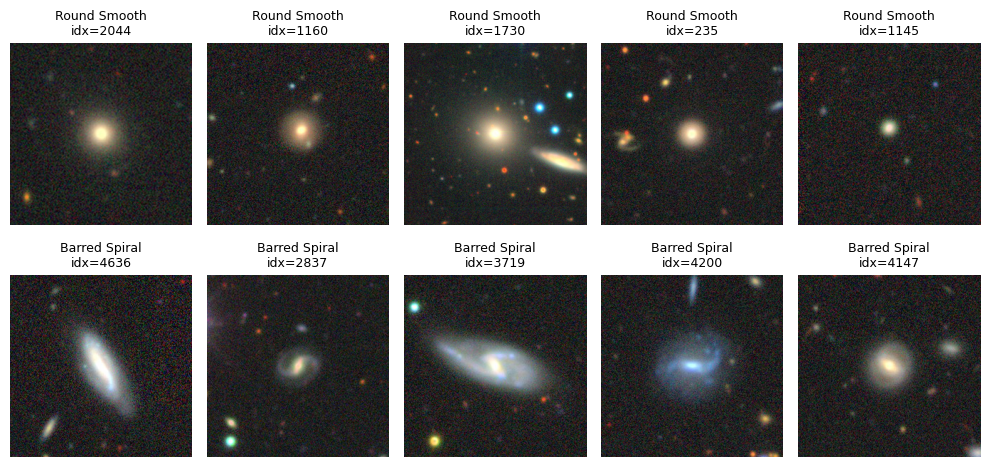

In [7]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
barred_spiral= np.sum(y)
total= len(y)
print(f"Hay {barred_spiral} barred spiral de un total de {total} galaxias")
print(f"Las round smooth componen un {(1-barred_spiral/total)*100:.3f}% de la muestra")

Hay 2043 barred spiral de un total de 4688 galaxias
Las round smooth componen un 56.421% de la muestra


1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
## Respuestas
- Las galaxias _smooth_ son visiblemente más suaves y redondas mientras que las _barred_ tienen una estructura espiral con un bulbo alargado.
- Esperamos que aprenda la intensidad de brillo, la forma, color, y quizá el tamaño relativo a la imagen.
- La proporción entre clases es más o menos balanceada, el accuracy de predecir la clase más frecuente sería de 56.4%

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [8]:
X_temp, X_test, y_temp,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=2026)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=2026)

In [9]:
# su codigo acá

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (3000, 256, 256, 3) (3000,)
Val: (750, 256, 256, 3) (750,)
Test: (938, 256, 256, 3) (938,)
Train classes: (array([0, 1], dtype=int32), array([1693, 1307]))
Val classes: (array([0, 1], dtype=int32), array([423, 327]))
Test classes: (array([0, 1], dtype=int32), array([529, 409]))


2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
## Respuesta
- Estos conjuntos son necesarios porque necesitamos que 1. la red aprenda con un set de datos grande, 2. necesitamos que compare sus resultados con un set no involucrado en el entrenamiento con el fin de minimizar la pérdida sin ser sobreajustado y 3. necesitamos un set de prueba que no tenga ningún _data leakage_ en el modelo para ver su desempeño real.

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

## Respuestas:
1. Usaremos 5 capas convolucionales. Una capa base y 4 capas convolucionales ocultas.
2. Usaremos 12 filtros en cada capa. Por simplicidad es la misma de cantidad de filtros por capa, el número de filtros es basado en nuestra lógica que se necesitaba una mayor cantidad de características.
3. ReLU, porque es la más estándar.
4. Sí, esto reduce las dimensiones y por lo tanto es mucho más rápido.
5. Sí, usaremos `GlobalAveragePooling`, creemos que un promedio 2D proporciona mejor informarción a la capa densa que le sigue.
6. Sí, usaremos _Dropout_. Para evitar que la red se hiperenfoque en alguna caracterítica morfológica en particular.
7. Debe tener una función sigmoide, porque es la versión diferenciable de una heaviside. y buscamos que la clasificación sea binaria.
8. Una Binary Cross Entropy, porque es un problema de clasificación binaria.

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(____, kernel_size=____, activation=____)
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.________________()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [10]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), #capa de normalización


    # Bloque convolucional 1
    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Bloque convolucional, agregue máximo 4
    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Parte final de clasificación, capa de pooling
    layers.GlobalAveragePooling2D(),

    layers.Dense(8, activation="relu"), #capa densa fully connected

    # Capa de salida
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary() #resumen de la arquitectura de la red



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 12)   │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 12)   │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 12)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,681 (22.19 KB)

 Trainable params: 5,681 (22.19 KB)

 Non-trainable params: 0 (0.00 B)

3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  

## Respuesta
Nuestra arquitectura actual es el resultado de múltiples pruebas sin embargo por honor al tiempo no podemos ejecutar el código múltiples veces para mostrar el proceso, se fueron variando parámetros a mano y estudiando como estos afectaban las métricas del modelo con el set de prueba hasta obtener un modelo con un desempeño satisfactorio.

In [11]:
# @title
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
#early_stop = tf.keras.callbacks.EarlyStopping(
#    monitor="val_loss",
#    patience=3,
#    restore_best_weights=True
#)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, #puede modificar este valor
    #Original 15
    batch_size=32,#puede modificar este valor
    #callbacks=[early_stop]
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.5617 - loss: 0.6830 - val_accuracy: 0.6093 - val_loss: 0.6844
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7273 - loss: 0.5530 - val_accuracy: 0.7507 - val_loss: 0.5369
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7763 - loss: 0.4803 - val_accuracy: 0.7133 - val_loss: 0.5511
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7873 - loss: 0.4740 - val_accuracy: 0.7773 - val_loss: 0.5128
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7830 - loss: 0.4837 - val_accuracy: 0.7160 - val_loss: 0.5568
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7943 - loss: 0.4553 - val_accuracy: 0.8067 - val_loss: 0.4696
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8077 - loss: 0.4357 - val_accuracy: 0.8000 - val_loss: 0.4604
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8037 - loss: 0.4387 - val_accuracy: 

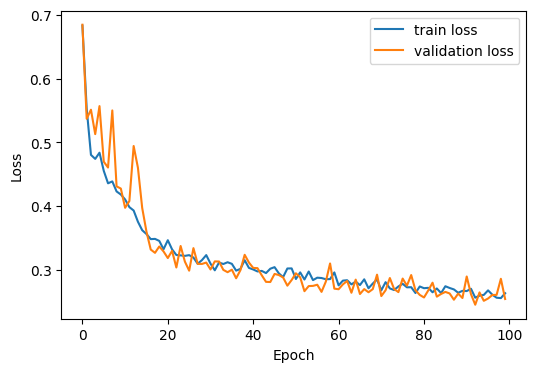

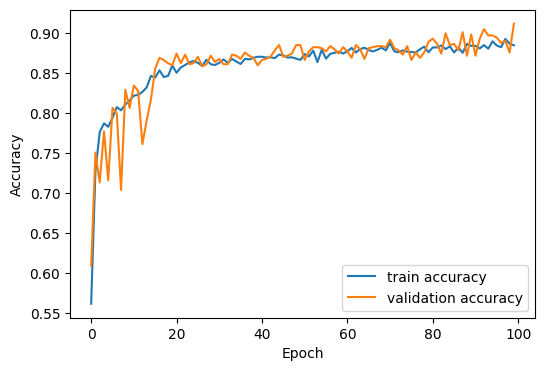

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
## Respuesta
El entrenamiento parece lo suficientemente razonable, pero se observa un poco de _overfitting_.

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8998 - loss: 0.2685
Test loss: 0.2685
Test accuracy: 0.8998


#### Genere la matriz de confusión y las métricas

In [14]:
y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

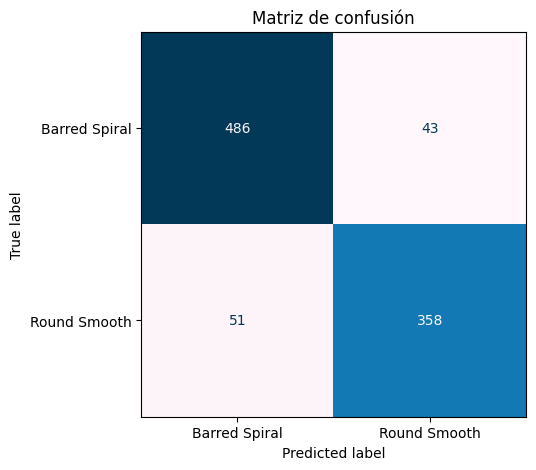

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
cm = confusion_matrix(y_test,y_pred)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Barred Spiral", "Round Smooth"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión")
plt.show()

In [16]:
print(classification_report(y_test,y_pred, target_names=["Barred Spiral", "Round Smooth"]))

               precision    recall  f1-score   support

Barred Spiral       0.91      0.92      0.91       529
 Round Smooth       0.89      0.88      0.88       409

     accuracy                           0.90       938
    macro avg       0.90      0.90      0.90       938
 weighted avg       0.90      0.90      0.90       938



5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
## Respuesta
El accuracy por si solo no es suficiente para evaluar el modelo, la precision del modelo también es importante y de hecho es mayor al accuracy.

#### Revise algunos ejemplos de galaxias mal clasificadas

### Galaxias mal clasificadas

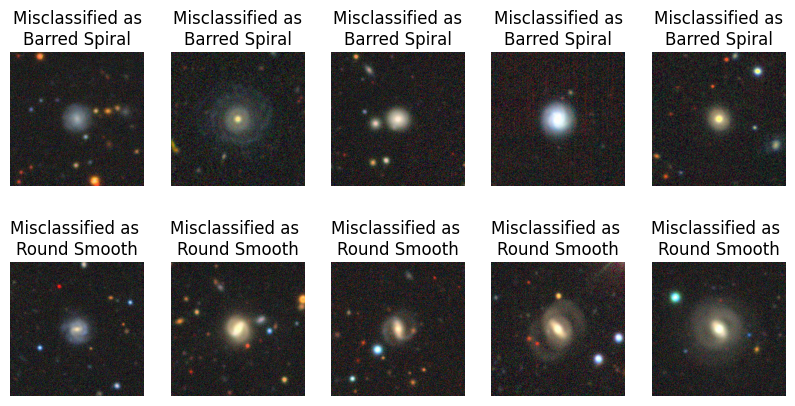

In [19]:
fake_barr = X_test[(y_pred==1) & (y_test==0)]
fake_round = X_test[(y_pred==0) & (y_test==1)]

fig, ax = plt.subplots(nrows=2,ncols=5,figsize=(10,5))
for i in range(5):
  ax[0][i].imshow(fake_barr[i])
  ax[0][i].axis("off")
  ax[0][i].set_title("Misclassified as\nBarred Spiral")
for i in range(5):
  ax[1][i].imshow(fake_round[i])
  ax[1][i].axis("off")
  ax[1][i].set_title("Misclassified as \nRound Smooth")

plt.show()

6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución
## Respuesta

Por lo visto, la principal causa es ambigüedad morfológica.
A las round mal clasificadas como barred parece confunde el halo de la galaxia con brazos espirales débiles, y para el caso contrario son muy redondas e incluso a veces casi indistinguibles para el ojo humano no entrenado.


#### Conclusiones y comentarios finales

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

## Respuesta

El modelo no parece estarse enfocando tanto en la morfología de las galaxias como lo haría un humano, si no en patrones ocultos para los que no podríamos tener interpretación.
A pesar de que esta fue una tarea para experimentar con CNN y familiarizarnos, creemos que el desempeño de nuestro modelo es bueno y satisfactorio.